# Comparison cistrans
Run any plot you need, only run setup and the window you are interested in.
Choose the data from the dropdown menu and adjust global parameters in setup, if needed.

In [70]:
#general imports
# import h5py
# import meteor
# import reciprocalspaceship as rs
import numpy as np
from scipy.ndimage import gaussian_filter

# my imports
from occupancy import *
from plotting3d import *
from generate_objects import *

In [71]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# "Latex style"
import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
}
)

# Setup

In [68]:
from compare_conds import * 
alpha_xtrs = default_alpha_xtrs()
alpha_trues = np.arange(0.05, 1, 0.1)
noise_levels = [0, 0.05, 0.1, 0.2, 0.3]
res_log, rows = main(alpha_xtrs, alpha_trues, noise_levels )

intersection slopes 0.0 3.110026483054377 34.56277087356799
intersection slopes 0.0 9.317847957264917 11.628909590004817
intersection slopes 0.0 15.457261222184249 7.0100653609277
intersection slopes 0.0 21.536464917832507 5.031299792322177
intersection slopes 0.0 27.547977789720512 3.933370801136522
intersection slopes 0.0 33.492470034411404 3.235246948257791
intersection slopes 0.02761167579455777 39.340882695064145 2.7553714319930367
intersection slopes 1.18329321127641 45.088231212680874 2.4350373574561806
intersection slopes 5.16283469098152 50.7590065983083 2.2392661192554475
intersection slopes 13.187714490187147 56.326320323652524 2.146062989245125
intersection slopes 0.0 1.8302604263939033 30.541096065372408
intersection slopes 0.0 8.1656009563682 13.181307598213886
intersection slopes 0.0 15.451503477094057 7.03448136628112
intersection slopes 0.0 24.375746903969837 4.5676699288702425
intersection slopes 0.0 26.662070618732535 4.038085244613646
intersection slopes 0.0 32.7977

In [65]:
res_log = pd.concat((res_log,res_log2))
# res_log2 = res_log

saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/plots/vary_noise_occu_pandda_nse.png
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../tex/figs/vary_noise_occu_pandda_nse.pdf


<Figure size 640x480 with 0 Axes>

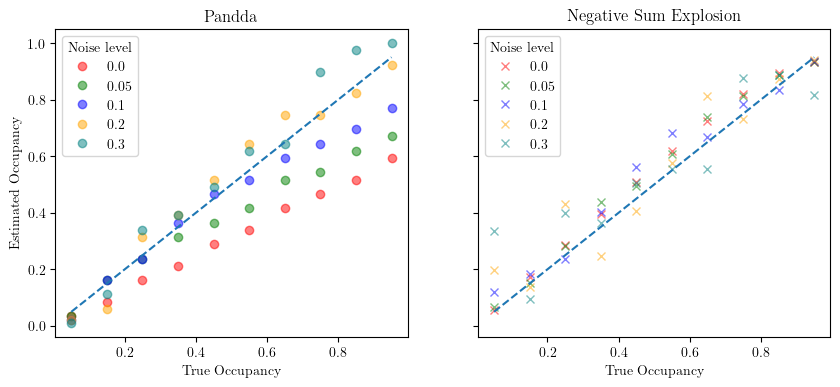

In [73]:
colors = 'r', 'g' ,'b','orange', "teal", "brown"
plt.figure()
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)
titles = ["Pandda", "Negative Sum Explosion"]
axs[0].set_ylabel("Estimated Occupancy")
for ax, title in zip(axs, titles):
    ax.set_title(title)
    for color, noise_level in zip(colors, np.unique(res_log.noise)):
        kwargs = {"color":color, "alpha" : 0.5, "label":noise_level}
        rslog = res_log[res_log.noise == noise_level]
        if title=="Pandda":
            ax.plot(rslog.true, rslog.pandda, "o",**kwargs)
        else:
            plt.plot(rslog.true, rslog.neg_sum, "x", **kwargs)
    ax.set_xlabel("True Occupancy")
    ax.plot(rslog.true, rslog.true, "--")
    ax.legend(title="Noise level")
    
save_fig(fig, "vary_noise_occu_pandda_nse")
# colors = 'r', 'g' ,'b','orange'
# plt.figure()
# plt.title()
# for color, noise_level in zip(colors, np.unique(res_log.noise)):
#     kwargs = {"color":color, "alpha" : 0.5, "label":noise_level}
#     rslog = res_log[res_log.noise == noise_level]
#     plt.plot(rslog.true, rslog.neg_sum, "x", **kwargs)
#     # plt.plot(rslog.true, rslog.pandda, "o",**kwargs)
# plt.plot(rslog.true, rslog.true, "--")
# plt.legend(title="Noise level")
# plt.show()
